In [13]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

In [2]:
fold_1_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

## Baseline Random Forest Model

In [5]:
# Initialize the Baseline Random Forest Classifier
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the model on the training data
rf_baseline.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [6]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

In [7]:
# Evaluate the model on the validation set
y_pred_baseline = rf_baseline.predict(X_val)
y_proba_baseline = rf_baseline.predict_proba(X_val)[:, 1]

Classification Report:
              precision    recall  f1-score   support

           0     0.9934    0.9519    0.9722    178711
           1     0.0835    0.4083    0.1387      1920

    accuracy                         0.9461    180631
   macro avg     0.5385    0.6801    0.5554    180631
weighted avg     0.9837    0.9461    0.9633    180631


Confusion Matrix:
[[170111   8600]
 [  1136    784]]

Precision: 0.0835
Recall:    0.4083
F1 Score:  0.1387
AUC-PR (Average Precision): 0.0891
ROC AUC:                   0.8546


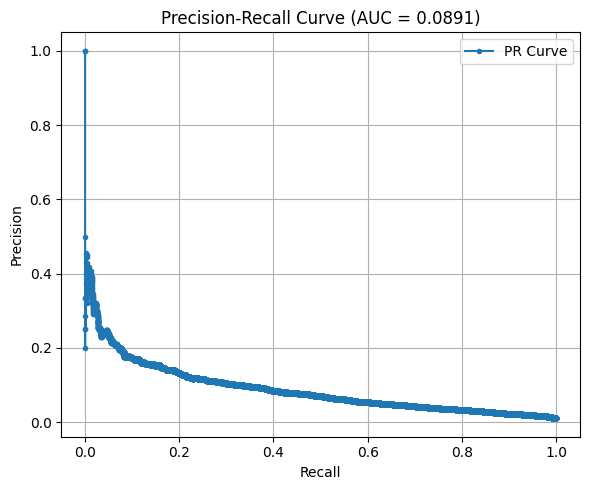

{'precision': 0.08354646206308611,
 'recall': 0.4083333333333333,
 'f1_score': 0.1387119603680113,
 'confusion_matrix': [[170111, 8600], [1136, 784]],
 'auc_pr': np.float64(0.08911421312759288),
 'roc_auc': np.float64(0.8545559692627576)}

In [8]:
evaluate_model(y_val, y_pred_baseline,y_proba_baseline)

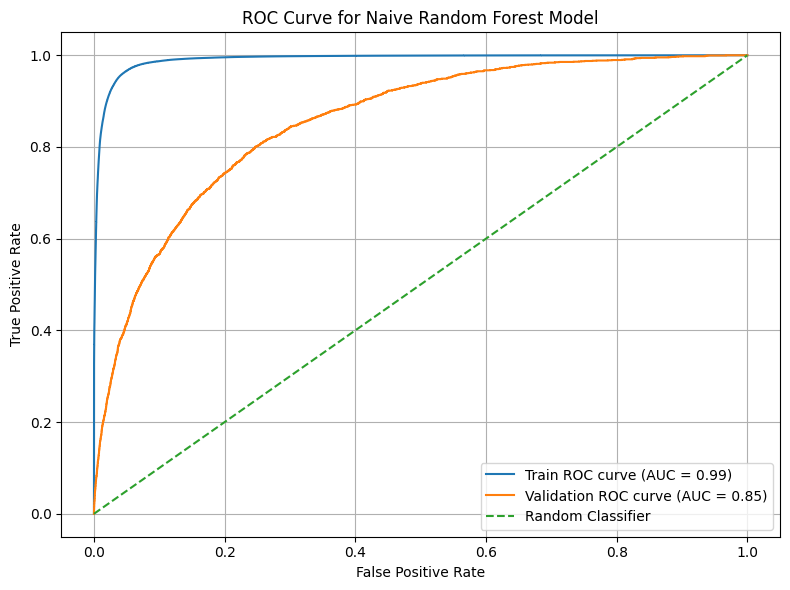

In [9]:
# Plot ROC curve for the model's performance on Train vs. Test (Validation)
# Get the probabilities for the positive class (fraud)
y_train_proba = rf_baseline.predict_proba(X_train)[:, 1]
y_val_proba = rf_baseline.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, rf_baseline.predict_proba(X_val)[:, 1])

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {roc_auc_score(y_train, y_train_proba):.2f})')
plt.plot(fpr_val, tpr_val, label=f'Validation ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naive Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Get Selected Features

In [10]:
# Initialize list to store selected features
selected_features_list = []

# Get feature importances from Naive Random Forest
feature_importances = rf_baseline.feature_importances_

# Create a DataFrame of feature names and their corresponding importance scores
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance
feature_df = feature_df.sort_values(by='Importance', ascending=False)

In [11]:
# Calculate Cumulative Feature Importance
cumulative_importance = np.cumsum(feature_importances[feature_df.index])  # Cumulative sum of feature importances
total_importance = cumulative_importance[-1]  # Total importance (sum of all feature importances)

# Set a threshold for cumulative importance (e.g., 95%)
threshold = 0.95
best_num_features = np.where(cumulative_importance >= threshold * total_importance)[0][0] + 1  # Get index where cumulative importance exceeds threshold

# Select top N features based on cumulative importance
selected_features = feature_df['Feature'].head(best_num_features).values

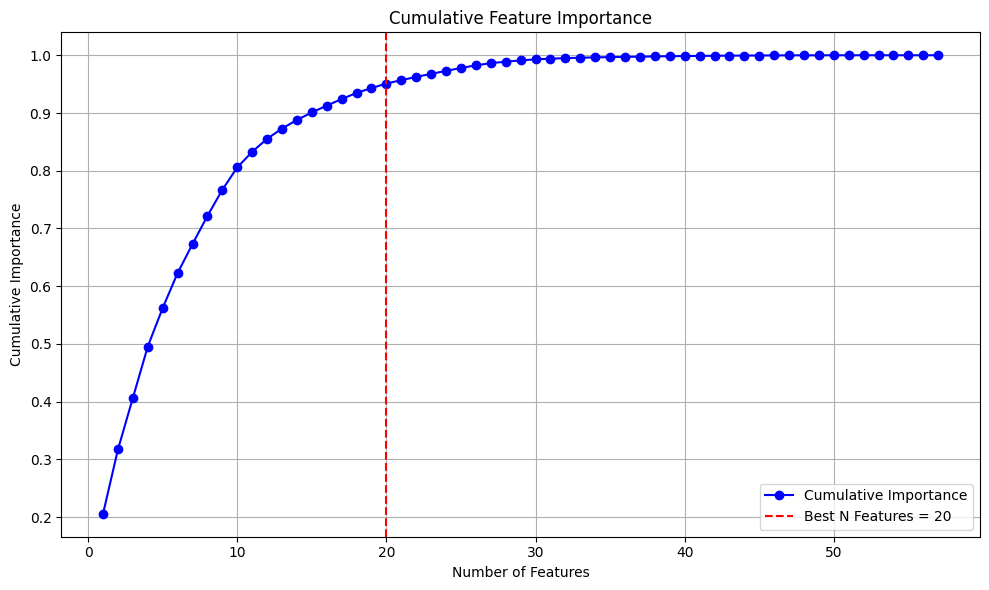

In [12]:
# Plot cumulative feature importance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_importance) + 1), cumulative_importance, marker='o', color='blue', label='Cumulative Importance')
plt.axvline(x=best_num_features, color='red', linestyle='--', label=f'Best N Features = {best_num_features}')  # Add a vertical line for the best N features
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## rf_model_2 with Selected Features & Hyperparameter Tuning

In [14]:
# Objective function for Optuna
def objective(trial, X_train, y_train, X_val, y_val):
    # Define the hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 10, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None])
    }

    # Initialize the Random Forest with suggested hyperparameters
    rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)

    # Fit the Random Forest model on the training data
    rf.fit(X_train, y_train)

    # Predict and calculate probabilities on the validation set
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)[:, 1]  # Get probability for class 1 (fraud)

    # Calculate evaluation metrics
    auc_roc = roc_auc_score(y_val, y_proba)
    auc_pr = average_precision_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)

    # Return the AUC-PR score as the objective for Optuna to maximize
    return auc_pr

In [16]:
# Tuned parameters storage
tuned_params_per_fold = []

# Phase 1: Tune with folds 1–4
for i in range(4):
    print(f"\nTuning Fold {i+1} (Validation)")

    # Split data into train and validation sets (fold 1-4 for training, fold i for validation)
    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    # Apply feature selection (using selected features)
    X_train_selected = X_train[selected_features]  # Use selected features
    X_val_selected = X_val[selected_features]      # Use selected features for validation

    # Sample 10% of the training data for hyperparameter tuning
    sampled_data_size = 0.1  # Sample 10% of the data
    X_train_sampled, _, y_train_sampled, _ = train_test_split(X_train_selected, y_train, 
                                                              train_size=sampled_data_size, 
                                                              random_state=42, 
                                                              stratify=y_train)

    # Create Optuna study for hyperparameter tuning (maximize auc pr)
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train_sampled, y_train_sampled, X_val_selected, y_val), 
                   n_trials=10, show_progress_bar=True)
    
    # Store the best hyperparameters from the study for this fold
    tuned_params_per_fold.append(study.best_params)

# After tuning, print the best parameters
print(f"Tuned parameters per fold: {tuned_params_per_fold}")


Tuning Fold 1 (Validation)


[I 2025-04-16 21:48:48,104] A new study created in memory with name: no-name-472cd4d9-0b4f-43f3-8be1-b0548c16b15a


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 21:49:11,958] Trial 0 finished with value: 0.09135924353290169 and parameters: {'n_estimators': 118, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.09135924353290169.
[I 2025-04-16 21:49:23,166] Trial 1 finished with value: 0.09146075929463028 and parameters: {'n_estimators': 55, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.09146075929463028.
[I 2025-04-16 21:50:52,829] Trial 2 finished with value: 0.056351624297782746 and parameters: {'n_estimators': 115, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.09146075929463028.
[I 2025-04-16 21:51:16,752] Trial 3 finished with value: 0.08439341772305078 and parameters: {'n_estimators': 136, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_le

[I 2025-04-16 21:54:43,484] A new study created in memory with name: no-name-693f8c75-c899-4694-b15b-14793661ca66


...

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 22:00:52,158] Trial 0 finished with value: 0.08572001027587785 and parameters: {'n_estimators': 86, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.08572001027587785.
[I 2025-04-16 22:01:21,244] Trial 1 finished with value: 0.09253009503558243 and parameters: {'n_estimators': 112, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.09253009503558243.
[I 2025-04-16 22:01:46,175] Trial 2 finished with value: 0.08743707803794296 and parameters: {'n_estimators': 67, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.09253009503558243.
[I 2025-04-16 22:02:22,969] Trial 3 finished with value: 0.09278522930919496 and parameters: {'n_estimators': 102, 'max_depth': 15, 'min_samples_split': 8, 'min_samp

[I 2025-04-16 22:05:32,711] A new study created in memory with name: no-name-8b32aaa8-2be9-4b68-a53a-ab292855bd7d


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 22:05:56,062] Trial 0 finished with value: 0.09063057183024108 and parameters: {'n_estimators': 121, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.09063057183024108.
[I 2025-04-16 22:06:14,561] Trial 1 finished with value: 0.0949587645982655 and parameters: {'n_estimators': 86, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.0949587645982655.
[I 2025-04-16 22:07:09,211] Trial 2 finished with value: 0.0804523001848278 and parameters: {'n_estimators': 64, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.0949587645982655.
[I 2025-04-16 22:07:27,294] Trial 3 finished with value: 0.08873468859236157 and parameters: {'n_estimators': 101, 'max_depth': 10, 'min_samples_split': 4, 'min_samp

In [18]:
# Get the best hyperparameters
best_params = tuned_params_per_fold[3]  

# Initialize the Random Forest model with the best hyperparameters
rf_model_2 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [19]:
# Train on full training data (folds 1-4) and evaluate on fold 5 (unseen data)
final_train_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train_full = final_train_data.drop(columns='fraud_bool')
y_train_full = final_train_data['fraud_bool']

X_train_selected_full = X_train_full[selected_features]  # Use the selected features

In [20]:
# Fit the model on all training data
rf_model_2.fit(X_train_selected_full, y_train_full)

RandomForestClassifier(class_weight='balanced', max_depth=14,
                       max_features='log2', min_samples_leaf=4,
                       min_samples_split=8, n_estimators=86, n_jobs=-1,
                       random_state=42)

In [21]:
# Load fold 5 data for evaluation on fold 5 (unseen data)
fold_5_val = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv")

In [22]:
# Evaluate on fold 5 (unseen data)
X_val_selected_5 = fold_5_val[selected_features]   # Use selected features, no fraud bool col
y_val_5 = fold_5_val['fraud_bool']

Classification Report:
              precision    recall  f1-score   support

           0     0.9926    0.9698    0.9810    178711
           1     0.1035    0.3250    0.1570      1920

    accuracy                         0.9629    180631
   macro avg     0.5480    0.6474    0.5690    180631
weighted avg     0.9831    0.9629    0.9723    180631


Confusion Matrix:
[[173307   5404]
 [  1296    624]]

Precision: 0.1035
Recall:    0.3250
F1 Score:  0.1570
AUC-PR (Average Precision): 0.0982
ROC AUC:                   0.8997


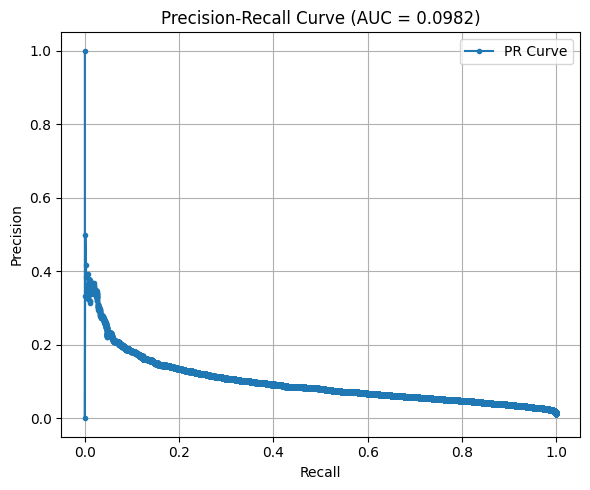

{'precision': 0.10351692103516921,
 'recall': 0.325,
 'f1_score': 0.15702063412179165,
 'confusion_matrix': [[173307, 5404], [1296, 624]],
 'auc_pr': np.float64(0.09816589472843343),
 'roc_auc': np.float64(0.8997001909973832)}

In [27]:
y_pred_model_2 = rf_model_2.predict(X_val_selected_5)
y_proba_model_2 = rf_model_2.predict_proba(X_val_selected_5)[:, 1]

evaluate_model(y_val_5, y_pred_model_2, y_proba_model_2)

## rf_model_3 with Hyperparameter Tuning Only

In [28]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [29]:
# Objective function for Optuna
def objective(trial, X_train, y_train, X_val, y_val):
    # Define the hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 10, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None])
    }

    # Initialize the Random Forest with suggested hyperparameters
    rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)

    # Fit the Random Forest model on the training data
    rf.fit(X_train, y_train)

    # Predict and calculate probabilities on the validation set
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)[:, 1]  # Get probability for class 1 (fraud)

    # Calculate evaluation metrics
    auc_roc = roc_auc_score(y_val, y_proba)
    auc_pr = average_precision_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)

    # Return the AUC-PR score as the objective for Optuna to maximize
    return auc_pr

In [30]:
# Tuned parameters storage
tuned_params_per_fold = []

# Phase 1: Tune with folds 1–4
for i in range(4):
    print(f"\nTuning Fold {i+1} (Validation)")

    # Split data into train and validation sets (fold 1-4 for training, fold i for validation)
    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    # Sample 10% of the training data for hyperparameter tuning
    sampled_data_size = 0.1  # Sample 10% of the data
    X_train_sampled, _, y_train_sampled, _ = train_test_split(X_train, y_train, 
                                                              train_size=sampled_data_size, 
                                                              random_state=42, 
                                                              stratify=y_train)

    # Create Optuna study for hyperparameter tuning (maximize auc pr)
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train_sampled, y_train_sampled, X_val, y_val), 
                   n_trials=10, show_progress_bar=True)
    
    # Store the best hyperparameters from the study for this fold
    tuned_params_per_fold.append(study.best_params)

# After tuning, print the best parameters
print(f"Tuned parameters per fold: {tuned_params_per_fold}")


Tuning Fold 1 (Validation)


[I 2025-04-16 23:15:28,302] A new study created in memory with name: no-name-22b70f36-4c6d-4eb2-bc9e-e91690d03ad5


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 23:15:39,417] Trial 0 finished with value: 0.08786859704428981 and parameters: {'n_estimators': 67, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.08786859704428981.
[I 2025-04-16 23:17:37,321] Trial 1 finished with value: 0.07175375704931684 and parameters: {'n_estimators': 88, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.08786859704428981.
[I 2025-04-16 23:18:02,586] Trial 2 finished with value: 0.09572083650178427 and parameters: {'n_estimators': 141, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.09572083650178427.
[I 2025-04-16 23:19:23,460] Trial 3 finished with value: 0.05364664343915157 and parameters: {'n_estimators': 73, 'max_depth': 10, 'min_samples_split': 8, 'min_samples

[I 2025-04-16 23:23:31,982] A new study created in memory with name: no-name-4e4981b7-ee92-4440-847a-380bce1dce98


...

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 23:38:10,018] Trial 0 finished with value: 0.06387067158107448 and parameters: {'n_estimators': 121, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.06387067158107448.
[I 2025-04-16 23:38:21,806] Trial 1 finished with value: 0.08884182378409686 and parameters: {'n_estimators': 87, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.08884182378409686.
[I 2025-04-16 23:40:32,615] Trial 2 finished with value: 0.05407487401737704 and parameters: {'n_estimators': 115, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'class_weight': None}. Best is trial 1 with value: 0.08884182378409686.
[I 2025-04-16 23:40:49,422] Trial 3 finished with value: 0.09906890417328867 and parameters: {'n_estimators': 101, 'max_depth': 14, 'min_samples_split': 9, 'min_samples

[I 2025-04-16 23:44:40,080] A new study created in memory with name: no-name-dab7099d-5aeb-4a61-945b-bc54cd947e63


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-04-16 23:44:52,563] Trial 0 finished with value: 0.09808600231629458 and parameters: {'n_estimators': 94, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.09808600231629458.
[I 2025-04-16 23:45:08,959] Trial 1 finished with value: 0.10956756692682891 and parameters: {'n_estimators': 109, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.10956756692682891.
[I 2025-04-16 23:48:15,032] Trial 2 finished with value: 0.07165682763696771 and parameters: {'n_estimators': 142, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 1 with value: 0.10956756692682891.
[I 2025-04-16 23:48:36,268] Trial 3 finished with value: 0.09496675906839604 and parameters: {'n_estimators': 130, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_lea

In [31]:
# Get the best hyperparameters
best_params = tuned_params_per_fold[3]  

# Initialize the Random Forest model with the best hyperparameters
rf_model_3 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [32]:
# Train on full training data (folds 1-4) and evaluate on fold 5 (unseen data)
final_train_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train_full = final_train_data.drop(columns='fraud_bool')
y_train_full = final_train_data['fraud_bool']

In [33]:
# Fit the model on all training data
rf_model_3.fit(X_train_full, y_train_full)

RandomForestClassifier(max_depth=14, max_features='log2', min_samples_leaf=2,
                       min_samples_split=3, n_estimators=85, n_jobs=-1,
                       random_state=42)

In [38]:
# Load fold 5 data for evaluation on fold 5 (unseen data)
fold_5_val = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv")

# Evaluate on fold 5 (unseen data)
X_val = fold_5_val.drop(columns='fraud_bool')  # Use selected features, no fraud bool col
y_val = fold_5_val['fraud_bool']

Classification Report:
              precision    recall  f1-score   support

           0     0.9933    0.9674    0.9802    178711
           1     0.1143    0.3917    0.1770      1920

    accuracy                         0.9613    180631
   macro avg     0.5538    0.6795    0.5786    180631
weighted avg     0.9839    0.9613    0.9716    180631


Confusion Matrix:
[[172886   5825]
 [  1168    752]]

Precision: 0.1143
Recall:    0.3917
F1 Score:  0.1770
AUC-PR (Average Precision): 0.1131
ROC AUC:                   0.9085


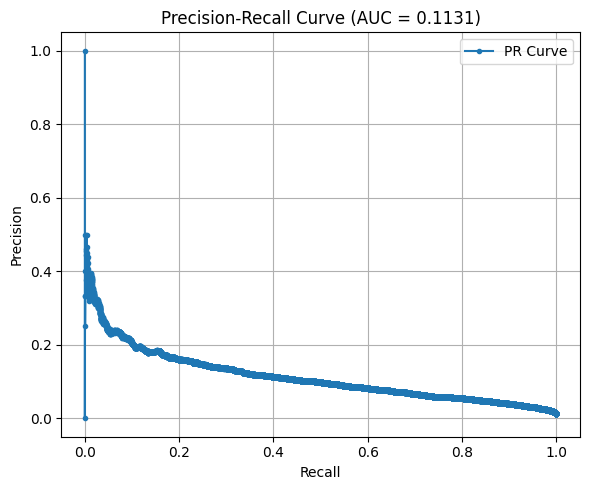

{'precision': 0.11433784400182453,
 'recall': 0.39166666666666666,
 'f1_score': 0.17700364834647522,
 'confusion_matrix': [[172886, 5825], [1168, 752]],
 'auc_pr': np.float64(0.11311875200345273),
 'roc_auc': np.float64(0.9085323904586177)}

In [39]:
y_pred_model_3 = rf_model_3.predict(X_val)
y_proba_model_3 = rf_model_3.predict_proba(X_val)[:, 1]

evaluate_model(y_val, y_pred_model_3, y_proba_model_3)